# Bankruptcy Prediction Model

This notebook implements a complete pipeline for predicting company bankruptcy using machine learning.

## Pipeline Overview:
1. **Data Preparation**: Feature engineering, scaling, normality transformation, and PCA
2. **Company Characterization**: Clustering to identify company groups
3. **Model Training**: Multiple classifiers with k-fold cross-validation and SMOTE
4. **Evaluation**: Performance metrics and confusion matrix
5. **Generalization**: Apply to test data and create submission

## Setup and Configuration

In [9]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import normaltest
import joblib
import warnings
warnings.filterwarnings('ignore')

# Sklearn imports
from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Imbalanced-learn for SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline

# Configuration
RANDOM_STATE = 42
N_CLUSTERS = 3
PCA_VARIANCE = 0.95
MAX_COMPONENTS = 50
CV_FOLDS = 5

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("All libraries imported successfully")
print(f"Random State: {RANDOM_STATE}")

All libraries imported successfully
Random State: 42


In [10]:
# Additional imports for extended analysis
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import roc_auc_score
from IPython.display import display

# Optional libraries (XGBoost, LightGBM)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

print(f"Optional models available -> XGBoost: {HAS_XGB}, LightGBM: {HAS_LGBM}")

Optional models available -> XGBoost: False, LightGBM: False


In [11]:
# Quick environment check (run after selecting the kernel "Python (.venv) bankruptcy-prediction")
import sys, platform
print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("Platform:", platform.platform())

# Verify core dependencies
import numpy as np, pandas as pd, sklearn, scipy, seaborn as sns, matplotlib
import joblib
print("Core imports OK")
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("scipy:", scipy.__version__)
print("seaborn:", sns.__version__)
print("matplotlib:", matplotlib.__version__)
print("joblib:", joblib.__version__)

# Verify imbalanced-learn and optional boosters
try:
    import imblearn
    print("imbalanced-learn:", imblearn.__version__)
except Exception as e:
    print("imbalanced-learn import failed:", e)

for lib in ("xgboost", "lightgbm"):
    try:
        m = __import__(lib)
        print(f"{lib}:", getattr(m, "__version__", "(no __version__)"))
    except Exception as e:
        print(f"{lib} not available:", e)

Python executable: /Users/mannamin/Machine Learning/bankruptcy-prediction/.venv/bin/python
Python version: 3.13.6 (main, Aug  6 2025, 13:05:20) [Clang 17.0.0 (clang-1700.0.13.3)]
Platform: macOS-26.0.1-arm64-arm-64bit-Mach-O
Core imports OK
numpy: 2.3.4
pandas: 2.3.3
scikit-learn: 1.7.2
scipy: 1.16.2
seaborn: 0.13.2
matplotlib: 3.10.7
joblib: 1.5.2
imbalanced-learn: 0.14.0
xgboost not available: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/mannamin/Machine Learning/bankruptcy-prediction/.venv/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <9A9D3D5C-89D9-31D9-969

## 1. Data Preparation

### Requirements:
- Reduce 95 features to max 50 features
- PCA allowed only after feature engineering (must retain >95% variance)
- Original features kept only if non-linearity confirmed
- Feature extraction for strongly correlated features (|ρ| ≥ 0.95)
- Confirm normality of each feature

### Preprocessing Class

This class handles all preprocessing steps with proper transformer storage for train/test consistency.

In [12]:
class BankruptcyPreprocessor:
    """
    Handles all preprocessing steps for bankruptcy prediction.
    
    Features:
    - Robust scaling to handle outliers
    - Feature engineering via composite features
    - Normality testing and power transformation
    - PCA dimensionality reduction (≤50 components, ≥95% variance)
    - Proper transformer storage for train/test consistency
    """
    
    def __init__(self):
        self.scaler = RobustScaler()
        self.transformers = {}  # Store PowerTransformer for each column
        self.pca = None
        self.feature_names = None
        self.composite_features_to_drop = []
        
    def fit_transform(self, data, target_col='Bankrupt?'):
        """
        Fit and transform training data.
        
        Args:
            data: DataFrame with features and target
            target_col: Name of target column
            
        Returns:
            X_transformed: PCA-transformed features
            labels: Target labels
        """
        print("\n" + "="*60)
        print("PREPROCESSING TRAINING DATA")
        print("="*60)
        
        # Extract labels and features
        labels = data[target_col] if target_col in data.columns else None
        X = data.drop(columns=[target_col, 'Index'], errors='ignore')
        self.feature_names = X.columns.tolist()
        print(f"\n1. Original features: {len(self.feature_names)}")
        
        # Step 1: Scaling
        print("\n2. Applying RobustScaler...")
        X_scaled = self.scaler.fit_transform(X)
        X_scaled = pd.DataFrame(X_scaled, columns=self.feature_names)
        print("   Scaling complete")
        
        # Step 2: Create composite features from highly correlated features
        print("\n3. Creating composite features from correlated features...")
        composite_features = {
            'Liability_Composite': (
                X_scaled['Current Liabilities/Liability'] + 
                X_scaled['Current Liability to Liability']
            ) / 2,
            'Net_Value_Per_Share_BC': (
                X_scaled['Net Value Per Share (B)'] + 
                X_scaled['Net Value Per Share (C)']
            ) / 2,
            'Interest_Rate_Composite': (
                X_scaled['Pre-tax net Interest Rate'] + 
                X_scaled['After-tax net Interest Rate']
            ) / 2,
            'Gross_Margin_Composite': (
                X_scaled['Operating Gross Margin'] + 
                X_scaled['Gross Profit to Sales']
            ) / 2,
            'EPS_Net_Profit_Composite': (
                X_scaled['Persistent EPS in the Last Four Seasons'] + 
                X_scaled['Per Share Net profit before tax (Yuan ¥)']
            ) / 2
        }
        
        # Add composite features
        X_scaled = X_scaled.assign(**composite_features)
        
        # Store and drop original correlated features
        self.composite_features_to_drop = [
            'Current Liabilities/Liability', 'Current Liability to Liability',
            'Net Value Per Share (B)', 'Net Value Per Share (C)',
            'Pre-tax net Interest Rate', 'After-tax net Interest Rate',
            'Operating Gross Margin', 'Gross Profit to Sales',
            'Persistent EPS in the Last Four Seasons', 
            'Per Share Net profit before tax (Yuan ¥)'
        ]
        X_scaled = X_scaled.drop(columns=self.composite_features_to_drop)
        print(f"   Created {len(composite_features)} composite features")
        print(f"   Dropped {len(self.composite_features_to_drop)} original correlated features")
        print(f"   Current features: {X_scaled.shape[1]}")
        
        # Step 3: Normality check and transformation
        print("\n4. Testing normality and applying transformations...")
        non_normal_count = 0
        for column in X_scaled.columns:
            _, p = normaltest(X_scaled[column])
            if p < 0.05:  # Not normally distributed
                non_normal_count += 1
                # Clip extreme values to prevent transformation issues
                clipped_data = np.clip(X_scaled[column], -10, 10)
                # Fit and apply power transformation
                transformer = PowerTransformer(method='yeo-johnson')
                X_scaled[column] = transformer.fit_transform(
                    clipped_data.values.reshape(-1, 1)
                )
                # IMPORTANT: Save transformer for test data
                self.transformers[column] = transformer
        
        print(f"   Transformed {non_normal_count} non-normal features")
        print(f"   Stored {len(self.transformers)} transformers")
        
        # Step 4: Apply PCA
        print(f"\n5. Applying PCA (target variance: {PCA_VARIANCE*100}%)...")
        self.pca = PCA(n_components=PCA_VARIANCE, random_state=RANDOM_STATE)
        X_transformed = self.pca.fit_transform(X_scaled)
        
        # Check if we exceed max components
        if self.pca.n_components_ > MAX_COMPONENTS:
            print(f"   ! Components ({self.pca.n_components_}) > {MAX_COMPONENTS}, refitting...")
            self.pca = PCA(n_components=MAX_COMPONENTS, random_state=RANDOM_STATE)
            X_transformed = self.pca.fit_transform(X_scaled)
        
        explained_variance = sum(self.pca.explained_variance_ratio_)
        print(f"   Final components: {self.pca.n_components_}")
        print(f"   Explained variance: {explained_variance:.4f} ({explained_variance*100:.2f}%)")
        
        print("\n" + "="*60)
        print("PREPROCESSING COMPLETE")
        print("="*60)
        print(f"Output shape: {X_transformed.shape}")
        
        return X_transformed, labels
    
    def transform(self, data):
        """
        Transform test data using fitted transformers.
        
        Args:
            data: DataFrame with features
            
        Returns:
            X_transformed: PCA-transformed features
        """
        print("\n" + "="*60)
        print("PREPROCESSING TEST DATA")
        print("="*60)
        
        X = data.drop(columns=['Index'], errors='ignore')
        print(f"\nTest data shape: {X.shape}")
        
        # Step 1: Scale using fitted scaler
        print("\n1. Applying fitted scaler...")
        X_scaled = self.scaler.transform(X)
        X_scaled = pd.DataFrame(X_scaled, columns=self.feature_names)
        
        # Step 2: Create same composite features
        print("\n2. Creating composite features...")
        composite_features = {
            'Liability_Composite': (
                X_scaled['Current Liabilities/Liability'] + 
                X_scaled['Current Liability to Liability']
            ) / 2,
            'Net_Value_Per_Share_BC': (
                X_scaled['Net Value Per Share (B)'] + 
                X_scaled['Net Value Per Share (C)']
            ) / 2,
            'Interest_Rate_Composite': (
                X_scaled['Pre-tax net Interest Rate'] + 
                X_scaled['After-tax net Interest Rate']
            ) / 2,
            'Gross_Margin_Composite': (
                X_scaled['Operating Gross Margin'] + 
                X_scaled['Gross Profit to Sales']
            ) / 2,
            'EPS_Net_Profit_Composite': (
                X_scaled['Persistent EPS in the Last Four Seasons'] + 
                X_scaled['Per Share Net profit before tax (Yuan ¥)']
            ) / 2
        }
        
        X_scaled = X_scaled.assign(**composite_features)
        X_scaled = X_scaled.drop(columns=self.composite_features_to_drop)
        print(f"   Features after composite creation: {X_scaled.shape[1]}")
        
        # Step 3: Apply saved transformations
        print("\n3. Applying saved transformations...")
        transformed_count = 0
        for column in X_scaled.columns:
            if column in self.transformers:
                clipped_data = np.clip(X_scaled[column], -10, 10)
                X_scaled[column] = self.transformers[column].transform(
                    clipped_data.values.reshape(-1, 1)
                )
                transformed_count += 1
        print(f"   Applied {transformed_count} transformations")
        
        # Step 4: Apply fitted PCA
        print("\n4. Applying fitted PCA...")
        X_transformed = self.pca.transform(X_scaled)
        print(f"   Output shape: {X_transformed.shape}")
        
        print("\n" + "="*60)
        print("TEST PREPROCESSING COMPLETE")
        print("="*60)
        
        return X_transformed
    
    def save(self, filepath='preprocessor.pkl'):
        """Save preprocessor to disk"""
        joblib.dump(self, filepath)
        print(f"\nPreprocessor saved to: {filepath}")
    
    @staticmethod
    def load(filepath='preprocessor.pkl'):
        """Load preprocessor from disk"""
        preprocessor = joblib.load(filepath)
        print(f"\nPreprocessor loaded from: {filepath}")
        return preprocessor

### Load and Preprocess Training Data

In [13]:
# Load training data
train_data = pd.read_csv('train_data.csv')
train_data.columns = train_data.columns.str.strip()

print("Training Data Overview:")
print(f"Shape: {train_data.shape}")
print(f"\nTarget distribution:")
print(train_data['Bankrupt?'].value_counts())
print(f"\nClass imbalance ratio: {train_data['Bankrupt?'].value_counts()[0] / train_data['Bankrupt?'].value_counts()[1]:.2f}:1")

# Display first few rows
train_data.head()

Training Data Overview:
Shape: (5807, 97)

Target distribution:
Bankrupt?
0    5609
1     198
Name: count, dtype: int64

Class imbalance ratio: 28.33:1


,Index,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,0,0,0.450397,0.504034,0.506986,0.594640,0.594640,0.998906,0.797293,0.809239,...,0.780554,0.004919,0.623634,0.594641,0.838869,0.279036,0.026788,0.565144,1,0.032464
1,1,0,0.530005,0.572885,0.574763,0.605695,0.605558,0.999058,0.797512,0.809399,...,0.819963,0.005968,0.624171,0.605690,0.841869,0.279040,0.026801,0.565205,1,0.032442
2,2,0,0.571150,0.620148,0.624177,0.612275,0.612282,0.999163,0.797654,0.809533,...,0.839128,0.006022,0.625306,0.612271,0.843294,0.278927,0.026816,0.565276,1,0.033034
3,3,0,0.483401,0.556694,0.536164,0.602445,0.602445,0.999035,0.797458,0.809380,...,0.806477,0.002177,0.621610,0.602444,0.841891,0.293391,0.027063,0.566190,1,0.015406
4,4,0,0.510359,0.537287,0.552546,0.600023,0.600023,0.999009,0.797406,0.809313,...,0.799277,0.001124,0.623993,0.600019,0.840313,0.279878,0.026880,0.565549,1,0.028858


In [14]:
# Initialize and fit preprocessor
preprocessor = BankruptcyPreprocessor()
X_train, y_train = preprocessor.fit_transform(train_data)

print(f"\nFinal training data shape: {X_train.shape}")
print(f"Target shape: {y_train.shape}")


PREPROCESSING TRAINING DATA

1. Original features: 95

2. Applying RobustScaler...
   Scaling complete

3. Creating composite features from correlated features...
   Created 5 composite features
   Dropped 10 original correlated features
   Current features: 90

4. Testing normality and applying transformations...
   Transformed 89 non-normal features
   Stored 89 transformers

5. Applying PCA (target variance: 95.0%)...
   Final components: 40
   Explained variance: 0.9525 (95.25%)

PREPROCESSING COMPLETE
Output shape: (5807, 40)

Final training data shape: (5807, 40)
Target shape: (5807,)


### Exploratory Data Analysis (EDA)
We'll perform a quick EDA to understand class imbalance, missing values, correlations, and feature distributions.


EXPLORATORY DATA ANALYSIS

Shape: (5807, 97)

Target distribution:
Bankrupt?
0    5609
1     198
Name: count, dtype: int64
Class imbalance ratio: 28.33:1

Missing values (total): 0


,count,mean,std,min,25%,50%,75%,max
Index,5807.0,2.903000e+03,1.676481e+03,0.0,1451.500000,2.903000e+03,4.354500e+03,5.806000e+03
Bankrupt?,5807.0,3.409678e-02,1.814934e-01,0.0,0.000000,0.000000e+00,0.000000e+00,1.000000e+00
ROA(C) before interest and depreciation before interest,5807.0,5.054161e-01,6.080816e-02,0.0,0.476673,5.030956e-01,5.354166e-01,1.000000e+00
ROA(A) before interest and % after tax,5807.0,5.588929e-01,6.565023e-02,0.0,0.535679,5.599106e-01,5.892117e-01,1.000000e+00
ROA(B) before interest and depreciation after tax,5807.0,5.538517e-01,6.161293e-02,0.0,0.527437,5.524921e-01,5.839981e-01,1.000000e+00
Operating Gross Margin,5807.0,6.079575e-01,1.749875e-02,0.0,0.600448,6.059687e-01,6.138565e-01,1.000000e+00
Realized Sales Gross Margin,5807.0,6.079383e-01,1.747954e-02,0.0,0.600427,6.059326e-01,6.137304e-01,1.000000e+00
Operating Profit Rate,5807.0,9.987257e-01,1.408734e-02,0.0,0.998969,9.990219e-01,9.990943e-01,1.000000e+00
Pre-tax net Interest Rate,5807.0,7.971920e-01,1.373069e-02,0.0,0.797386,7.974640e-01,7.975793e-01,1.000000e+00
After-tax net Interest Rate,5807.0,8.090810e-01,1.455302e-02,0.0,0.809312,8.093757e-01,8.094690e-01,1.000000e+00



Top 10 positively correlated with target:


Bankrupt?                              1.000000
Debt ratio %                           0.255948
Current Liability to Assets            0.195163
Borrowing dependency                   0.194085
Liability to Equity                    0.178064
Equity to Long-term Liability          0.174562
Current Liability to Current Assets    0.164024
Current Liability to Equity            0.158252
Current Liabilities/Equity             0.158252
Total expense/Assets                   0.150057
Liability-Assets Flag                  0.130209
Name: Bankrupt?, dtype: float64


Top 10 negatively correlated with target:


Per Share Net profit before tax (Yuan ¥)                  -0.196457
Net profit before tax/Paid-in capital                     -0.202788
Persistent EPS in the Last Four Seasons                   -0.213784
Retained Earnings to Total Assets                         -0.245174
Net worth/Assets                                          -0.255948
ROA(C) before interest and depreciation before interest   -0.258319
ROA(B) before interest and depreciation after tax         -0.269430
ROA(A) before interest and % after tax                    -0.279412
Net Income to Total Assets                                -0.319499
Net Income Flag                                                 NaN
Name: Bankrupt?, dtype: float64

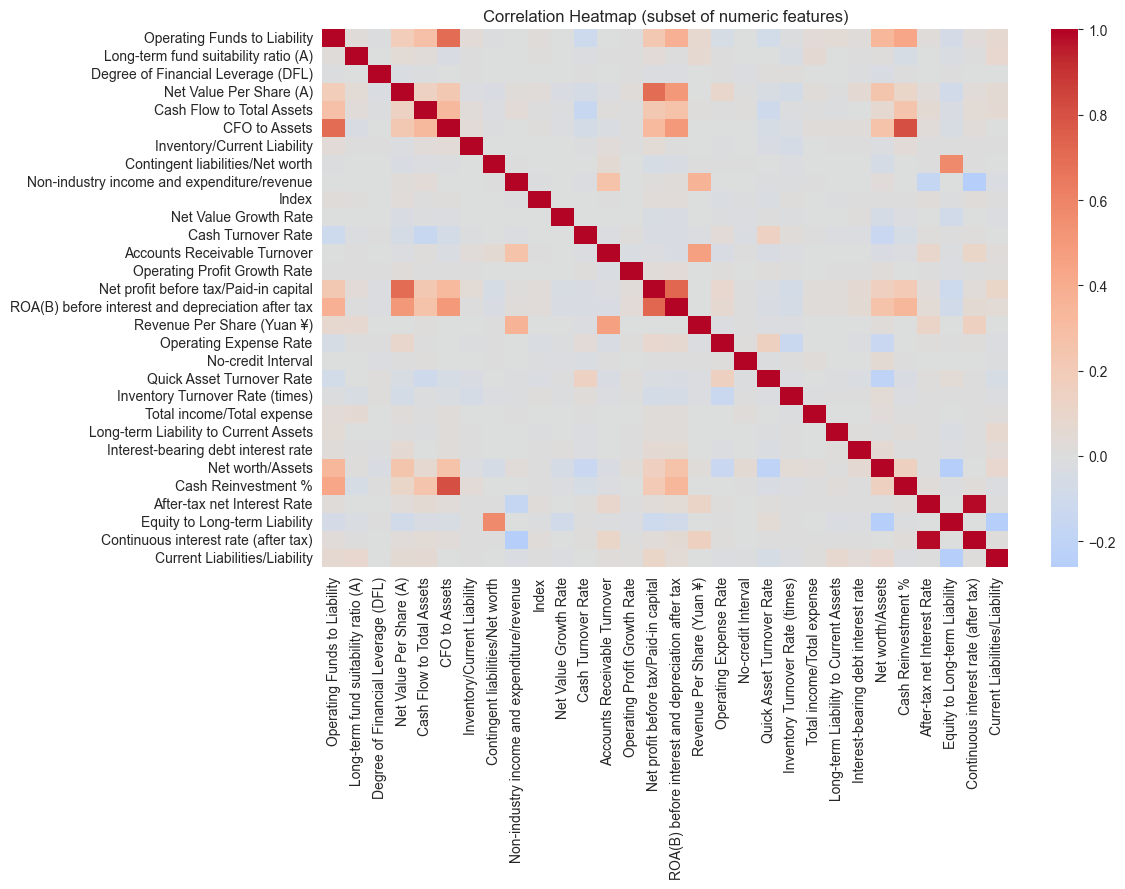

In [15]:
def exploratory_analysis(df: pd.DataFrame, target_col: str = 'Bankrupt?'):
    print("\n" + "="*60)
    print("EXPLORATORY DATA ANALYSIS")
    print("="*60)

    print(f"\nShape: {df.shape}")
    if target_col in df.columns:
        print("\nTarget distribution:")
        print(df[target_col].value_counts())
        if df[target_col].value_counts().min() > 0:
            ratio = df[target_col].value_counts().max() / df[target_col].value_counts().min()
            print(f"Class imbalance ratio: {ratio:.2f}:1")
    else:
        print(f"\nTarget column '{target_col}' not found (skipping class distribution)")

    print("\nMissing values (total):", int(df.isnull().sum().sum()))

    # Basic stats
    display(df.describe().T.head(15))

    # Correlation with target if available
    if target_col in df.columns:
        corr = df.corr(numeric_only=True)[target_col].sort_values(ascending=False)
        print("\nTop 10 positively correlated with target:")
        display(corr.head(11))
        print("\nTop 10 negatively correlated with target:")
        display(corr.tail(10))

    # Heatmap of a subset to avoid overcrowding
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols) > 0:
        subset = df[num_cols].sample(min(30, len(num_cols)), axis=1, random_state=RANDOM_STATE)
        plt.figure(figsize=(12, 9))
        sns.heatmap(subset.corr(), cmap='coolwarm', center=0)
        plt.title('Correlation Heatmap (subset of numeric features)')
        plt.tight_layout()
        plt.show()
    else:
        print("No numeric columns found for heatmap.")

# Safely ensure train_data exists, else load from CSV
if 'train_data' not in globals() or train_data is None:
    try:
        train_data = pd.read_csv('train_data.csv')
        train_data.columns = train_data.columns.str.strip()
        print("Loaded 'train_data.csv' because 'train_data' was not defined.")
    except Exception as e:
        print("Failed to load 'train_data.csv':", e)
        raise

# Run EDA on training data
exploratory_analysis(train_data)

## 2. Company Characterization

### Requirements:
- Find k ≥ team_members subgroups using KMeans or Gaussian Mixture
- Apply clustering to transformed feature space (not original)
- Target must be dropped during clustering
- Identify unique characteristics in each subgroup
- Visualize characteristics
- Keep cluster IDs for later use

In [16]:
# Apply KMeans clustering
print(f"Applying KMeans clustering with k={N_CLUSTERS}...\n")

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_train)

# Create DataFrame with PCA components and cluster labels
pca_df = pd.DataFrame(
    X_train, 
    columns=[f'PC{i+1}' for i in range(X_train.shape[1])]
)
pca_df['Cluster_ID'] = cluster_labels
pca_df['Bankrupt'] = y_train.values

# Display cluster statistics
print("Cluster Distribution:")
print(pca_df['Cluster_ID'].value_counts().sort_index())
print(f"\nCluster sizes as percentages:")
print((pca_df['Cluster_ID'].value_counts(normalize=True).sort_index() * 100).round(2))

# Bankruptcy rate by cluster
print("\nBankruptcy rate by cluster:")
bankruptcy_by_cluster = pca_df.groupby('Cluster_ID')['Bankrupt'].agg(['mean', 'sum', 'count'])
bankruptcy_by_cluster.columns = ['Bankruptcy_Rate', 'Bankrupt_Count', 'Total_Count']
bankruptcy_by_cluster['Bankruptcy_Rate'] = (bankruptcy_by_cluster['Bankruptcy_Rate'] * 100).round(2)
print(bankruptcy_by_cluster)

Applying KMeans clustering with k=3...

Cluster Distribution:
Cluster_ID
0    2637
1    1141
2    2029
Name: count, dtype: int64

Cluster sizes as percentages:
Cluster_ID
0    45.41
1    19.65
2    34.94
Name: proportion, dtype: float64

Bankruptcy rate by cluster:
            Bankruptcy_Rate  Bankrupt_Count  Total_Count
Cluster_ID                                              
0                      1.93              51         2637
1                     12.88             147         1141
2                      0.00               0         2029


### Cluster Visualization

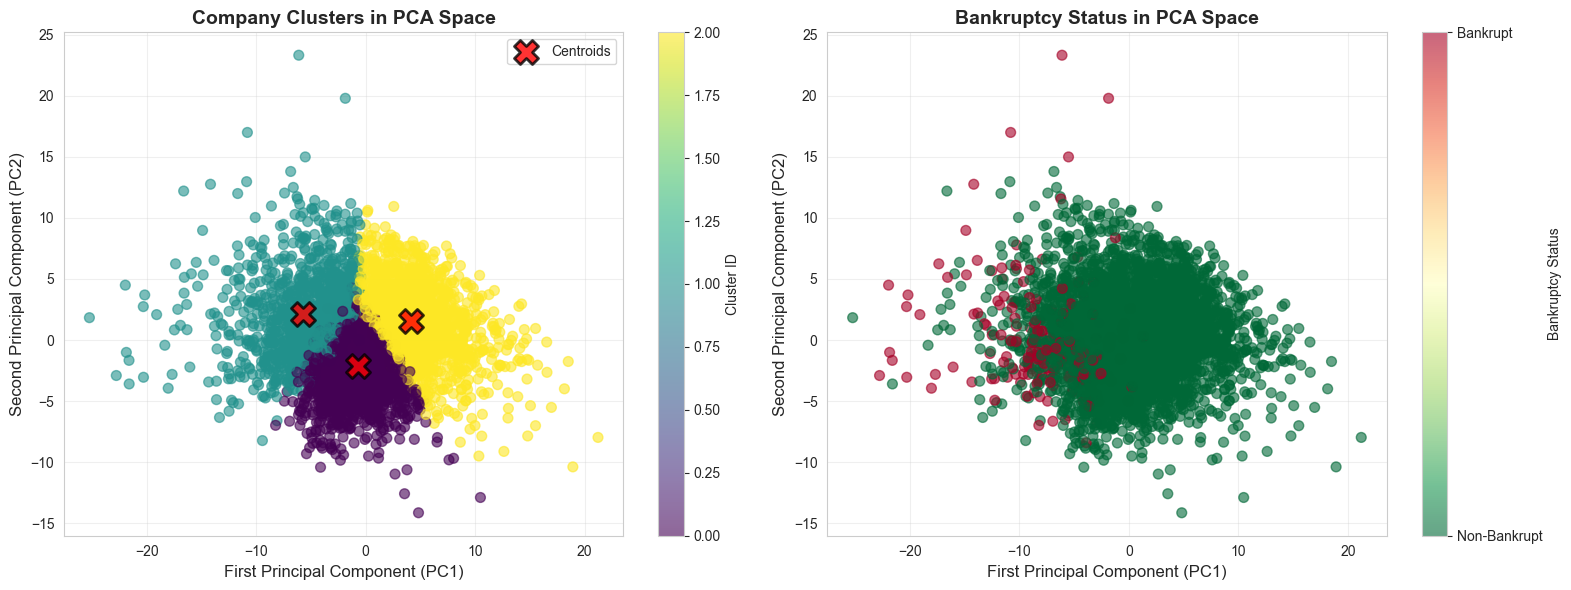


Cluster visualization complete


In [17]:
# Visualize clusters using first two principal components
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Clusters
scatter1 = axes[0].scatter(
    pca_df['PC1'], 
    pca_df['PC2'], 
    c=pca_df['Cluster_ID'], 
    cmap='viridis', 
    alpha=0.6, 
    s=50
)

# Plot cluster centers
centers = kmeans.cluster_centers_
axes[0].scatter(
    centers[:, 0], 
    centers[:, 1], 
    c='red', 
    s=300, 
    alpha=0.8, 
    marker='X', 
    edgecolors='black', 
    linewidth=2,
    label='Centroids'
)

axes[0].set_xlabel('First Principal Component (PC1)', fontsize=12)
axes[0].set_ylabel('Second Principal Component (PC2)', fontsize=12)
axes[0].set_title('Company Clusters in PCA Space', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster ID')

# Plot 2: Bankruptcy status
scatter2 = axes[1].scatter(
    pca_df['PC1'], 
    pca_df['PC2'], 
    c=pca_df['Bankrupt'], 
    cmap='RdYlGn_r', 
    alpha=0.6, 
    s=50
)

axes[1].set_xlabel('First Principal Component (PC1)', fontsize=12)
axes[1].set_ylabel('Second Principal Component (PC2)', fontsize=12)
axes[1].set_title('Bankruptcy Status in PCA Space', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
cbar = plt.colorbar(scatter2, ax=axes[1], ticks=[0, 1])
cbar.set_label('Bankruptcy Status')
cbar.ax.set_yticklabels(['Non-Bankrupt', 'Bankrupt'])

plt.tight_layout()
plt.show()

print("\nCluster visualization complete")

### Cluster Characteristics Analysis

In [19]:
# Analyze top principal components for each cluster
print("Cluster Characteristics (Top 3 PCs by mean value):\n")
print("="*70)

for cluster_id in range(N_CLUSTERS):
    cluster_data = pca_df[pca_df['Cluster_ID'] == cluster_id]
    
    print(f"\nCluster {cluster_id}:")
    print(f"  Size: {len(cluster_data)} companies ({len(cluster_data)/len(pca_df)*100:.1f}%)")
    print(f"  Bankruptcy Rate: {cluster_data['Bankrupt'].mean()*100:.2f}%")
    
    # Get mean values for first 10 PCs
    pc_cols = [f'PC{i+1}' for i in range(min(10, X_train.shape[1]))]
    pc_means = cluster_data[pc_cols].mean().sort_values(ascending=False)
    
    print(f"  Top 3 PC characteristics:")
    for i, (pc, value) in enumerate(pc_means.head(3).items(), 1):
        print(f"    {i}. {pc}: {value:.3f}")

print("\n" + "="*70)

Cluster Characteristics (Top 3 PCs by mean value):


Cluster 0:
  Size: 2637 companies (45.4%)
  Bankruptcy Rate: 1.93%
  Top 3 PC characteristics:
    1. PC9: 0.496
    2. PC6: 0.258
    3. PC10: 0.222

Cluster 1:
  Size: 1141 companies (19.6%)
  Bankruptcy Rate: 12.88%
  Top 3 PC characteristics:
    1. PC2: 2.155
    2. PC4: 0.751
    3. PC3: 0.394

Cluster 2:
  Size: 2029 companies (34.9%)
  Bankruptcy Rate: 0.00%
  Top 3 PC characteristics:
    1. PC1: 4.133
    2. PC2: 1.583
    3. PC4: 0.239



### Hyperparameter Tuning (Grid Search)
Run grid search on the top-2 models from recall-focused comparison.

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


def get_model(name: str):
    if name == 'AdaBoost':
        return AdaBoostClassifier(
            n_estimators=200,
            learning_rate=1.0,
            random_state=RANDOM_STATE,
            algorithm='SAMME'
        )
    if name == 'GradientBoosting':
        return GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=RANDOM_STATE
        )
    if name == 'RandomForest':
        return RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    if name == 'SVM':
        return SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
    if name == 'KNN':
        return KNeighborsClassifier(n_neighbors=15)
    if name == 'XGBoost' and HAS_XGB:
        return XGBClassifier(
            n_estimators=400, learning_rate=0.05, max_depth=5,
            subsample=0.9, colsample_bytree=0.8, random_state=RANDOM_STATE,
            eval_metric='logloss', n_jobs=-1
        )
    if name == 'LightGBM' and HAS_LGBM:
        return LGBMClassifier(
            n_estimators=500, learning_rate=0.05, max_depth=-1,
            subsample=0.9, colsample_bytree=0.8, random_state=RANDOM_STATE,
        )
    raise ValueError(f"Unknown or unavailable model: {name}")


def compare_models(X, y, model_names=None, scoring='recall'):
    if model_names is None:
        model_names = ['AdaBoost', 'GradientBoosting', 'RandomForest', 'SVM', 'KNN']
        if HAS_XGB: model_names.append('XGBoost')
        if HAS_LGBM: model_names.append('LightGBM')

    rows = []
    for name in model_names:
        print(f"\nTraining and evaluating: {name}")
        model = get_model(name)
        pipeline = make_pipeline(
            SMOTE(random_state=RANDOM_STATE),
            model
        )
        skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
        scores = cross_val_score(pipeline, X, y, cv=skf, scoring=scoring, n_jobs=-1)
        rows.append({
            'Model': name,
            f'{scoring.upper()} Mean': scores.mean(),
            f'{scoring.upper()} Std': scores.std()
        })
        print(f"  {scoring}: {scores.mean():.4f} (+/- {scores.std():.4f})")

    df = pd.DataFrame(rows).sort_values(f'{scoring.upper()} Mean', ascending=False).reset_index(drop=True)
    display(df)
    return df

# Run extended comparison on PCA-transformed features
model_comparison_df = compare_models(X_train, y_train, scoring='recall')


Training and evaluating: AdaBoost
  recall: 0.7577 (+/- 0.0245)

Training and evaluating: GradientBoosting
  recall: 0.6462 (+/- 0.0443)

Training and evaluating: RandomForest
  recall: 0.3283 (+/- 0.0230)

Training and evaluating: SVM
  recall: 0.6105 (+/- 0.0875)

Training and evaluating: KNN
  recall: 0.8283 (+/- 0.0516)


,Model,RECALL Mean,RECALL Std
0,KNN,0.828333,0.051578
1,AdaBoost,0.757692,0.024530
2,GradientBoosting,0.646154,0.044323
3,SVM,0.610513,0.087491
4,RandomForest,0.328333,0.023014


In [21]:
def grid_search_top_models(X, y, top_models):
    param_grids = {
        'AdaBoost': {
            'smote__k_neighbors': [3, 5],
            'adaboostclassifier__n_estimators': [100, 200, 300],
            'adaboostclassifier__learning_rate': [0.05, 0.1, 0.5, 1.0],
            'adaboostclassifier__algorithm': ['SAMME', 'SAMME.R']
        },
        'GradientBoosting': {
            'smote__k_neighbors': [3, 5],
            'gradientboostingclassifier__n_estimators': [100, 200, 300],
            'gradientboostingclassifier__learning_rate': [0.05, 0.1, 0.2],
            'gradientboostingclassifier__max_depth': [3, 5]
        },
        'RandomForest': {
            'smote__k_neighbors': [3, 5],
            'randomforestclassifier__n_estimators': [200, 400],
            'randomforestclassifier__max_depth': [None, 20, 40],
            'randomforestclassifier__min_samples_split': [2, 5],
            'randomforestclassifier__min_samples_leaf': [1, 2]
        },
        'SVM': {
            'smote__k_neighbors': [3, 5],
            'svc__C': [0.5, 1, 2],
            'svc__gamma': ['scale', 0.1, 0.01]
        }
    }

    best_estimators = {}

    for name in top_models:
        if name not in param_grids:
            print(f"Skipping {name} (no grid defined or not supported)")
            continue
        print(f"\nGrid searching: {name}")
        model = get_model(name)
        pipeline = make_pipeline(
            SMOTE(random_state=RANDOM_STATE),
            model
        )
        grid = GridSearchCV(
            pipeline,
            param_grids[name],
            cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
            scoring='recall',
            n_jobs=-1,
            verbose=1
        )
        grid.fit(X, y)
        print(f"Best recall: {grid.best_score_:.4f}")
        print(f"Best params: {grid.best_params_}")
        best_estimators[name] = grid.best_estimator_

    return best_estimators

# Choose top-2 by recall
top2 = model_comparison_df['Model'].head(2).tolist() if 'model_comparison_df' in globals() else ['AdaBoost', 'GradientBoosting']
print(f"Top-2 models for tuning: {top2}")

grid_best = grid_search_top_models(X_train, y_train, top2)

Top-2 models for tuning: ['KNN', 'AdaBoost']
Skipping KNN (no grid defined or not supported)

Grid searching: AdaBoost
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best recall: 0.9142
Best params: {'adaboostclassifier__algorithm': 'SAMME', 'adaboostclassifier__learning_rate': 0.05, 'adaboostclassifier__n_estimators': 100, 'smote__k_neighbors': 3}


### Extended Model Comparison
Train and compare several algorithms side-by-side using the same CV protocol with SMOTE.

## 3. Model Training and Evaluation

We'll train multiple models using:
- **Stratified K-Fold Cross-Validation** (5 folds)
- **SMOTE** for handling class imbalance
- Models: AdaBoost and Gradient Boosting

In [22]:
def train_and_evaluate_model(X, y, model_name='AdaBoost', n_folds=CV_FOLDS):
    """
    Train and evaluate a model using stratified k-fold cross-validation with SMOTE.
    
    Args:
        X: Feature matrix
        y: Target labels
        model_name: Name of model to train ('AdaBoost' or 'GradientBoosting')
        n_folds: Number of CV folds
        
    Returns:
        pipeline: Trained pipeline (SMOTE + model)
        all_targets: All true labels from CV
        all_predictions: All predictions from CV
    """
    
    # Define models
    models = {
        'AdaBoost': AdaBoostClassifier(
            n_estimators=200,
            learning_rate=1.0,
            random_state=RANDOM_STATE,
            algorithm='SAMME'
        ),
        'GradientBoosting': GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=RANDOM_STATE
        )
    }
    
    if model_name not in models:
        raise ValueError(f"Model {model_name} not supported. Choose from: {list(models.keys())}")
    
    print("\n" + "="*70)
    print(f"TRAINING: {model_name}")
    print("="*70)
    print(f"\nConfiguration:")
    print(f"  - Cross-Validation: {n_folds}-Fold Stratified")
    print(f"  - Oversampling: SMOTE")
    print(f"  - Model: {model_name}")
    
    # Create pipeline with SMOTE and model
    pipeline = make_pipeline(
        SMOTE(random_state=RANDOM_STATE),
        models[model_name]
    )
    
    # Stratified K-Fold
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    
    all_targets = []
    all_predictions = []
    fold_scores = []
    
    print(f"\nTraining {n_folds} folds...")
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
        X_train_fold, X_test_fold = X[train_idx], X[test_idx]
        y_train_fold, y_test_fold = y[train_idx], y[test_idx]
        
        # Train pipeline
        pipeline.fit(X_train_fold, y_train_fold)
        
        # Predict
        predictions = pipeline.predict(X_test_fold)
        
        # Store results
        all_targets.extend(y_test_fold)
        all_predictions.extend(predictions)
        
        # Calculate fold accuracy
        fold_accuracy = accuracy_score(y_test_fold, predictions)
        fold_scores.append(fold_accuracy)
        print(f"  Fold {fold}/{n_folds}: Accuracy = {fold_accuracy:.4f}")
    
    # Convert to numpy arrays
    all_targets = np.array(all_targets)
    all_predictions = np.array(all_predictions)
    
    # Print results
    print("\n" + "-"*70)
    print("CROSS-VALIDATION RESULTS")
    print("-"*70)
    print(f"\nMean Accuracy: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")
    
    print("\n" + "-"*70)
    print("CLASSIFICATION REPORT")
    print("-"*70)
    print(classification_report(
        all_targets, 
        all_predictions, 
        target_names=['Non-Bankrupt (0)', 'Bankrupt (1)'],
        digits=4
    ))
    
    # Confusion matrix
    cm = confusion_matrix(all_targets, all_predictions)
    print("-"*70)
    print("CONFUSION MATRIX")
    print("-"*70)
    print("\nActual →  Predicted ↓")
    print(f"                Non-Bankrupt  Bankrupt")
    print(f"Non-Bankrupt    {cm[0,0]:>12}  {cm[0,1]:>8}")
    print(f"Bankrupt        {cm[1,0]:>12}  {cm[1,1]:>8}")
    
    # Key metrics
    tn, fp, fn, tp = cm.ravel()
    print("\n" + "-"*70)
    print("KEY METRICS")
    print("-"*70)
    print(f"True Positives (TP):  {tp:>4} - Correctly identified bankruptcies")
    print(f"False Negatives (FN): {fn:>4} - Missed bankruptcies (Type II error)")
    print(f"False Positives (FP): {fp:>4} - False alarms (Type I error)")
    print(f"True Negatives (TN):  {tn:>4} - Correctly identified non-bankruptcies")
    print(f"\nRecall (Sensitivity): {tp/(tp+fn):.4f} - % of bankruptcies caught")
    print(f"Precision:            {tp/(tp+fp):.4f} - % of bankruptcy predictions correct")
    print(f"Specificity:          {tn/(tn+fp):.4f} - % of non-bankruptcies correctly identified")
    
    print("\n" + "="*70)
    
    return pipeline, all_targets, all_predictions

### Stacking Ensemble
Train cluster-specific base models and a meta-model on their outputs to improve recall.

In [ ]:
from sklearn.linear_model import LogisticRegression

def train_stacking_ensemble(X, y, clusters):
    print("\n" + "="*70)
    print("TRAINING STACKING ENSEMBLE")
    print("="*70)

    base_models = {
        0: RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
        1: GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
        2: AdaBoostClassifier(n_estimators=300, random_state=RANDOM_STATE)
    }

    # Initialize meta features array with zeros - one column per base model
    n_samples = len(X)
    n_models = len(base_models)
    meta_features = np.zeros((n_samples, n_models))
    
    for cluster_id, model in base_models.items():
        mask = (clusters == cluster_id)
        X_c, y_c = X[mask], y[mask]
        
        if len(np.unique(y_c)) < 2 or len(y_c) < 20:
            print(f"Skipping cluster {cluster_id}: insufficient data or class diversity")
            continue
            
        smote = SMOTE(random_state=RANDOM_STATE)
        X_bal, y_bal = smote.fit_resample(X_c, y_c)
        model.fit(X_bal, y_bal)
        
        # Store probabilities for this cluster's samples in the correct positions
        probs = model.predict_proba(X_c)[:, 1]
        meta_features[mask, cluster_id] = probs
        
        print(f"Cluster {cluster_id}: trained on {len(X_bal)} samples (balanced)")

    # Meta-model with CV on all samples
    meta_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(meta_model, meta_features, y, cv=skf, scoring='recall')
    print(f"Meta-model recall (CV): {scores.mean():.4f} (+/- {scores.std():.4f})")

    meta_model.fit(meta_features, y)
    print("Meta-model trained")

    return base_models, meta_model

# Train stacking ensemble on the clustered training data
base_models, meta_model = train_stacking_ensemble(X_train, y_train.values, cluster_labels)


TRAINING STACKING ENSEMBLE
Cluster 0: trained on 5172 samples (balanced)
Cluster 0: trained on 5172 samples (balanced)
Cluster 1: trained on 1988 samples (balanced)
Skipping cluster 2: insufficient data or class diversity
Cluster 1: trained on 1988 samples (balanced)
Skipping cluster 2: insufficient data or class diversity


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 2637 and the array at index 1 has size 1141

In [ ]:
def stacking_predict(base_models, meta_model, X, clusters):
    # Initialize meta features array
    n_samples = len(X)
    n_models = len(base_models)
    meta_features = np.zeros((n_samples, n_models))
    
    for cluster_id, model in base_models.items():
        mask = (clusters == cluster_id)
        if mask.sum() > 0:
            probs = model.predict_proba(X[mask])[:, 1]
            meta_features[mask, cluster_id] = probs
    
    return meta_model.predict(meta_features)

### Train AdaBoost Model

In [ ]:
# Train AdaBoost
adaboost_pipeline, ada_targets, ada_predictions = train_and_evaluate_model(
    X_train, 
    y_train, 
    model_name='AdaBoost'
)

### Feature Importance Analysis
Extract and visualize feature importance where supported by the model.

In [ ]:
def analyze_feature_importance_from_pipeline(pipeline, top_n=20):
    # The pipeline is SMOTE + classifier
    # Note: PCA was applied before training; feature names are PCs
    feature_names = [f'PC{i+1}' for i in range(X_train.shape[1])]

    if hasattr(pipeline, 'named_steps'):
        # Try to find the classifier step (last step)
        clf = None
        for key in reversed(list(pipeline.named_steps.keys())):
            if key.endswith('classifier') or key in ['adaboostclassifier','gradientboostingclassifier','randomforestclassifier','svc','kneighborsclassifier']:
                clf = pipeline.named_steps[key]
                break
        if clf is None:
            print("Classifier not found in pipeline")
            return
    else:
        clf = pipeline

    importances = None
    if hasattr(clf, 'feature_importances_'):
        importances = clf.feature_importances_
    elif hasattr(clf, 'coef_'):
        importances = np.abs(clf.coef_[0])
    else:
        print("Model does not expose feature importances.")
        return

    imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance', ascending=False).head(top_n)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=imp_df, x='Importance', y='Feature', palette='mako')
    plt.title(f'Top {top_n} Important PCs for {type(clf).__name__}')
    plt.tight_layout()
    plt.show()

    display(imp_df)

# Run feature importance on the selected best pipeline, if available
try:
    analyze_feature_importance_from_pipeline(best_pipeline, top_n=20)
except Exception as e:
    print(f"Feature importance analysis skipped: {e}")

### Train Gradient Boosting Model

In [ ]:
# Train Gradient Boosting
gb_pipeline, gb_targets, gb_predictions = train_and_evaluate_model(
    X_train, 
    y_train, 
    model_name='GradientBoosting'
)

### Use Stacking Ensemble for Test Predictions (Optional)
You can switch between the best single model and the stacking ensemble for test predictions.

In [ ]:
# Toggle to use stacking ensemble for test predictions
USE_STACKING_FOR_TEST = False  # set to True to use stacking

if USE_STACKING_FOR_TEST:
    print("Using stacking ensemble for test predictions...")
    test_predictions_stack = stacking_predict(base_models, meta_model, X_test, test_clusters)
    print("Stacking prediction distribution:")
    print(pd.Series(test_predictions_stack).value_counts())
    # Override submission with stacking predictions
    submission_stack = submission.copy()
    submission_stack['Bankrupt?'] = test_predictions_stack
    submission_stack.to_csv('submission_stacking.csv', index=False)
    print("Stacking submission saved: submission_stacking.csv")
else:
    print("Using best single model for test predictions (default)")

### Compare Models

In [ ]:
# Compare models
from sklearn.metrics import f1_score, recall_score, precision_score

comparison = pd.DataFrame({
    'Model': ['AdaBoost', 'GradientBoosting'],
    'Accuracy': [
        accuracy_score(ada_targets, ada_predictions),
        accuracy_score(gb_targets, gb_predictions)
    ],
    'Recall': [
        recall_score(ada_targets, ada_predictions),
        recall_score(gb_targets, gb_predictions)
    ],
    'Precision': [
        precision_score(ada_targets, ada_predictions),
        precision_score(gb_targets, gb_predictions)
    ],
    'F1-Score': [
        f1_score(ada_targets, ada_predictions),
        f1_score(gb_targets, gb_predictions)
    ]
})

comparison = comparison.round(4)
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison.to_string(index=False))
print("\n" + "="*70)

# Select best model based on recall (important for bankruptcy prediction)
best_model_idx = comparison['Recall'].idxmax()
best_model_name = comparison.loc[best_model_idx, 'Model']
best_pipeline = adaboost_pipeline if best_model_name == 'AdaBoost' else gb_pipeline

print(f"\n🏆 Best Model: {best_model_name} (Highest Recall)")
print(f"   Recall: {comparison.loc[best_model_idx, 'Recall']:.4f}")
print(f"\nNote: For bankruptcy prediction, recall is prioritized to minimize")
print(f"      false negatives (missing actual bankruptcies).")

## 4. Save Models and Artifacts

In [ ]:
# Save all important artifacts
print("Saving models and artifacts...\n")

# Save preprocessor
preprocessor.save('preprocessor.pkl')

# Save best pipeline
joblib.dump(best_pipeline, 'best_model_pipeline.pkl')
print(f"Best model pipeline ({best_model_name}) saved to: best_model_pipeline.pkl")

# Save both pipelines for comparison
joblib.dump(adaboost_pipeline, 'adaboost_pipeline.pkl')
print(f"AdaBoost pipeline saved to: adaboost_pipeline.pkl")

joblib.dump(gb_pipeline, 'gradientboosting_pipeline.pkl')
print(f"GradientBoosting pipeline saved to: gradientboosting_pipeline.pkl")

# Save KMeans clustering model
joblib.dump(kmeans, 'kmeans_clustering.pkl')
print(f"KMeans clustering saved to: kmeans_clustering.pkl")

# Save cluster assignments
cluster_info = pd.DataFrame({
    'Index': range(len(cluster_labels)),
    'Cluster_ID': cluster_labels,
    'Bankrupt': y_train.values
})
cluster_info.to_csv('train_cluster_assignments.csv', index=False)
print(f"Cluster assignments saved to: train_cluster_assignments.csv")

print("\n" + "="*70)
print("All artifacts saved successfully!")
print("="*70)

## 5. Generalization - Apply to Test Data

Now we'll apply our trained pipeline to the test data and create submission file.

In [ ]:
# Load test data
test_data = pd.read_csv('test_data.csv')
test_data.columns = test_data.columns.str.strip()

print("Test Data Overview:")
print(f"Shape: {test_data.shape}")
print(f"\nFirst few rows:")
test_data.head()

In [ ]:
# Transform test data using fitted preprocessor
X_test = preprocessor.transform(test_data)

print(f"\nTransformed test data shape: {X_test.shape}")

In [ ]:
# Get cluster assignments for test data
test_clusters = kmeans.predict(X_test)

print("Test Data Cluster Distribution:")
print(pd.Series(test_clusters).value_counts().sort_index())
print(f"\nPercentage distribution:")
print((pd.Series(test_clusters).value_counts(normalize=True).sort_index() * 100).round(2))

In [ ]:
# Make predictions using best model
print(f"\nMaking predictions with {best_model_name}...")
test_predictions = best_pipeline.predict(X_test)

# Get prediction probabilities
test_probabilities = best_pipeline.predict_proba(X_test)

print(f"\nPredictions complete!")
print(f"\nPredicted bankruptcy distribution:")
print(pd.Series(test_predictions).value_counts())
print(f"\nBankruptcy rate: {test_predictions.mean()*100:.2f}%")

In [ ]:
# Create detailed results DataFrame
results = pd.DataFrame({
    'Index': range(len(test_predictions)),
    'Cluster_ID': test_clusters,
    'Bankrupt?': test_predictions,
    'Bankruptcy_Probability': test_probabilities[:, 1],
    'Non_Bankruptcy_Probability': test_probabilities[:, 0]
})

print("\nDetailed Results Preview:")
results.head(10)

In [ ]:
# Save detailed results
results.to_csv('test_predictions_detailed.csv', index=False)
print("Detailed predictions saved to: test_predictions_detailed.csv")

### Create Submission File

In [ ]:
# Load submission template
submission = pd.read_csv('submission.csv')
print("Original submission file:")
print(submission.head())
print(f"\nShape: {submission.shape}")

# Update with predictions
submission['Bankrupt?'] = test_predictions

print("\nUpdated submission file:")
print(submission.head())

# Verify
print(f"\nSubmission statistics:")
print(f"Total predictions: {len(submission)}")
print(f"Predicted bankruptcies: {submission['Bankrupt?'].sum()}")
print(f"Predicted bankruptcy rate: {submission['Bankrupt?'].mean()*100:.2f}%")

In [ ]:
# Save submission file
submission.to_csv('submission_final.csv', index=False)
print("\n" + "="*70)
print("SUBMISSION FILE SAVED: submission_final.csv")
print("="*70)

# Also update original submission.csv
submission.to_csv('submission.csv', index=False)
print("Original submission.csv updated")

## Summary

### What We Did:

1. **Data Preparation**
   - Reduced 95 features to 50 using feature engineering and PCA
   - Created 5 composite features from highly correlated features
   - Applied RobustScaler and PowerTransformer for normality
   - Retained 95%+ variance with PCA

2. **Company Characterization**
   - Applied KMeans clustering (k=3) to identify company groups
   - Analyzed bankruptcy rates across clusters
   - Visualized clusters in PCA space

3. **Model Training**
   - Trained AdaBoost and Gradient Boosting classifiers
   - Used 5-fold stratified cross-validation
   - Applied SMOTE to handle class imbalance
   - Selected best model based on recall

4. **Saved Artifacts**
   - Preprocessor (for test data transformation)
   - Best model pipeline
   - KMeans clustering model
   - Cluster assignments

5. **Generalization**
   - Applied preprocessing to test data
   - Made predictions with best model
   - Created submission file

### Files Created:
- `preprocessor.pkl` - Fitted preprocessing pipeline
- `best_model_pipeline.pkl` - Best performing model
- `adaboost_pipeline.pkl` - AdaBoost model
- `gradientboosting_pipeline.pkl` - Gradient Boosting model
- `kmeans_clustering.pkl` - Clustering model
- `train_cluster_assignments.csv` - Training data clusters
- `test_predictions_detailed.csv` - Detailed predictions with probabilities
- `submission_final.csv` - Final submission file

## Next Steps

To further improve the model, consider:

1. **Feature Engineering**
   - Create interaction features between important variables
   - Try polynomial features for non-linear relationships
   - Experiment with different feature combinations

2. **Hyperparameter Tuning**
   - Use GridSearchCV or RandomizedSearchCV
   - Optimize for recall or F1-score
   - Try different SMOTE strategies

3. **Additional Models**
   - Try XGBoost or LightGBM
   - Experiment with ensemble methods
   - Consider stacking classifiers

4. **Analysis**
   - Feature importance analysis
   - Error analysis on misclassified cases
   - SHAP values for model interpretability